# AVIP 2026 Task 2: Titanic EDA

This notebook inspects, cleans, and analyzes the Titanic dataset using only `data/titanic.csv`.

## Imports and loading

In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Dataset overview

Exact duplicate rows are rows with identical values in every column. They are treated as duplicate records for this analysis.

In [27]:
print(f"Shape: {df.shape}")
print("Column names:", df.columns.tolist())
display(df.dtypes.to_frame("data_type"))
display(df.isna().sum().to_frame("missing_count"))
print(f"Duplicate rows: {df.duplicated().sum()}")
display(df.head())

Shape: (891, 15)
Column names: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,data_type
survived,int64
pclass,int64
sex,str
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,str
class,str
who,str


,missing_count
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Duplicate rows: 107


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Data cleaning

Cleaning is performed on `df_clean`, leaving the original dataframe unchanged. The 107 exact duplicate rows are removed, retaining the first occurrence. Missing `age` values are filled with the median because it is a robust numeric summary. Missing `embarked` and `embark_town` values are filled with their respective modes because these are categorical variables. `deck` is dropped because 688 of its values are missing, making it too sparse for reliable imputation.

In [28]:
df_clean = df.copy().drop_duplicates().copy()
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
for column in ["embarked", "embark_town"]:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])
df_clean = df_clean.drop(columns="deck")

df_clean["family_size"] = df_clean["sibsp"] + df_clean["parch"] + 1
df_clean["is_alone"] = df_clean["family_size"] == 1
df_clean = df_clean.drop_duplicates().copy()

print(f"Cleaned shape: {df_clean.shape}")
display(df_clean.isna().sum().to_frame("missing_count"))
print(f"Remaining duplicate rows: {df_clean.duplicated().sum()}")
display(df_clean.head())
df_clean.to_csv("../data/titanic_cleaned.csv", index=False)

Cleaned shape: (780, 16)


,missing_count
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


Remaining duplicate rows: 0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,True


## Feature engineering

`family_size` is `sibsp + parch + 1`, counting the passenger and recorded siblings, spouses, parents, and children. `is_alone` is `True` when `family_size` equals 1.

## Visualizations

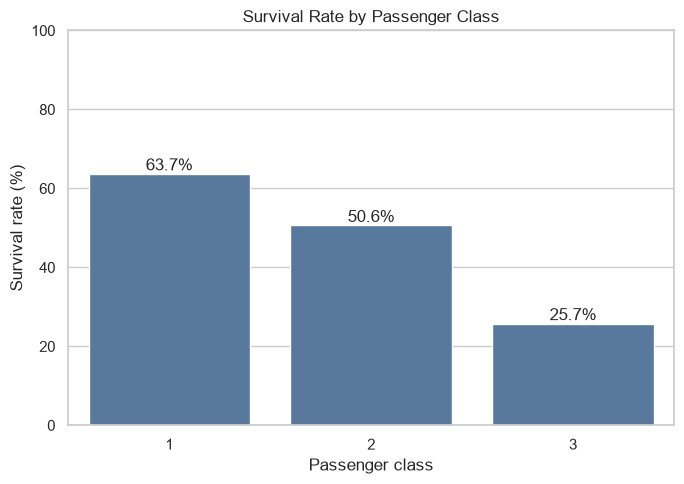

,pclass,survival_rate_percent
0,1,63.679245
1,2,50.609756
2,3,25.742574


In [29]:
charts_path = Path("../charts")
charts_path.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")

survival_by_class = df_clean.groupby("pclass", as_index=False)["survived"].mean()
survival_by_class["survival_rate_percent"] = survival_by_class["survived"] * 100
plt.figure(figsize=(7, 5))
ax = sns.barplot(data=survival_by_class, x="pclass", y="survival_rate_percent", color="#4C78A8")
ax.set(title="Survival Rate by Passenger Class", xlabel="Passenger class", ylabel="Survival rate (%)")
ax.set_ylim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.savefig(charts_path / "survival_by_class.png", dpi=150)
plt.show()
display(survival_by_class[["pclass", "survival_rate_percent"]])

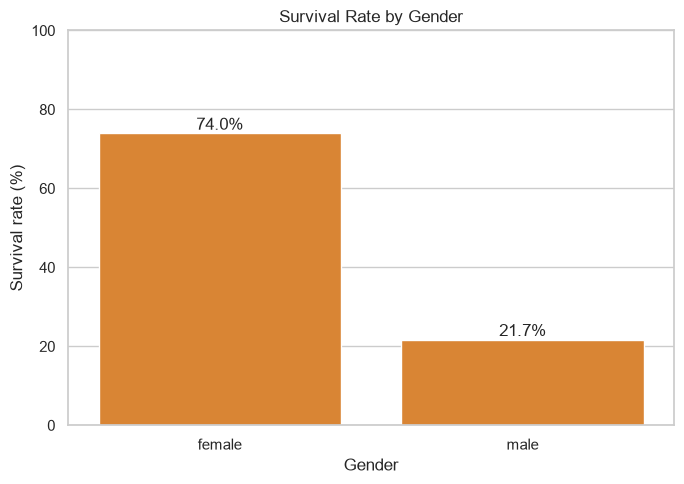

,sex,survival_rate_percent
0,female,73.972603
1,male,21.721311


In [30]:
survival_by_gender = df_clean.groupby("sex", as_index=False)["survived"].mean()
survival_by_gender["survival_rate_percent"] = survival_by_gender["survived"] * 100
plt.figure(figsize=(7, 5))
ax = sns.barplot(data=survival_by_gender, x="sex", y="survival_rate_percent", color="#F58518")
ax.set(title="Survival Rate by Gender", xlabel="Gender", ylabel="Survival rate (%)")
ax.set_ylim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.savefig(charts_path / "survival_by_gender.png", dpi=150)
plt.show()
display(survival_by_gender[["sex", "survival_rate_percent"]])

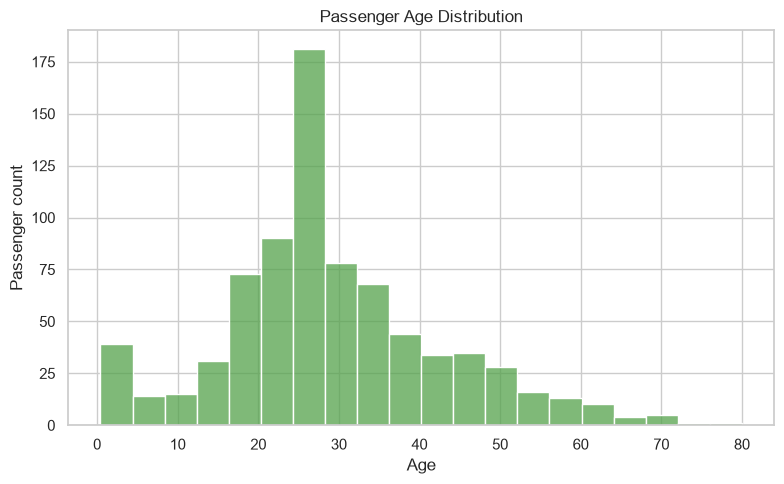

Age observations: 780
Age median: 28.25


In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x="age", bins=20, color="#54A24B", edgecolor="white")
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passenger count")
plt.tight_layout()
plt.savefig(charts_path / "age_distribution.png", dpi=150)
plt.show()
print(f"Age observations: {df_clean['age'].count()}")
print(f"Age median: {df_clean['age'].median():.2f}")

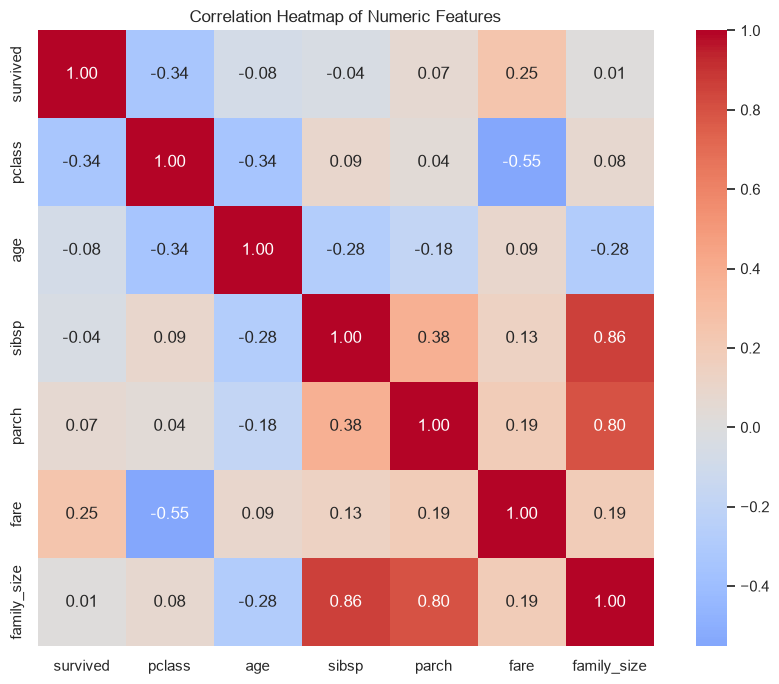

,survived,pclass,age,sibsp,parch,fare,family_size
survived,1.000000,-0.336244,-0.078050,-0.037597,0.069669,0.246669,0.013996
pclass,-0.336244,1.000000,-0.340878,0.086788,0.038975,-0.552440,0.077922
age,-0.078050,-0.340878,1.000000,-0.278886,-0.182903,0.092280,-0.282208
sibsp,-0.037597,0.086788,-0.278886,1.000000,0.380596,0.134127,0.860061
parch,0.069669,0.038975,-0.182903,0.380596,1.000000,0.191055,0.799131
fare,0.246669,-0.552440,0.092280,0.134127,0.191055,1.000000,0.192601
family_size,0.013996,0.077922,-0.282208,0.860061,0.799131,0.192601,1.000000


In [32]:
numeric_features = ["survived", "pclass", "age", "sibsp", "parch", "fare", "family_size"]
correlation_matrix = df_clean[numeric_features].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig(charts_path / "correlation_heatmap.png", dpi=150)
plt.show()
display(correlation_matrix)

## Key Observations

- Passenger class survival rates are available in `survival_by_class`; the chart and table identify the class with the highest and lowest observed rates.
- Gender survival rates are available in `survival_by_gender`; the chart and table identify the observed difference between groups.
- The cleaned dataset contains 780 records, and the age histogram uses the median-imputed age values.
- The correlation heatmap shows calculated associations among survival, class, age, family variables, and fare; correlations do not establish causation.

## Conclusion

The cleaned Titanic dataset supports comparisons of survival by passenger class and gender.
The age distribution summarizes the passenger ages after median imputation.
The correlation heatmap provides a compact numeric summary for further analysis.
All findings are descriptive and are based only on the supplied Titanic records.